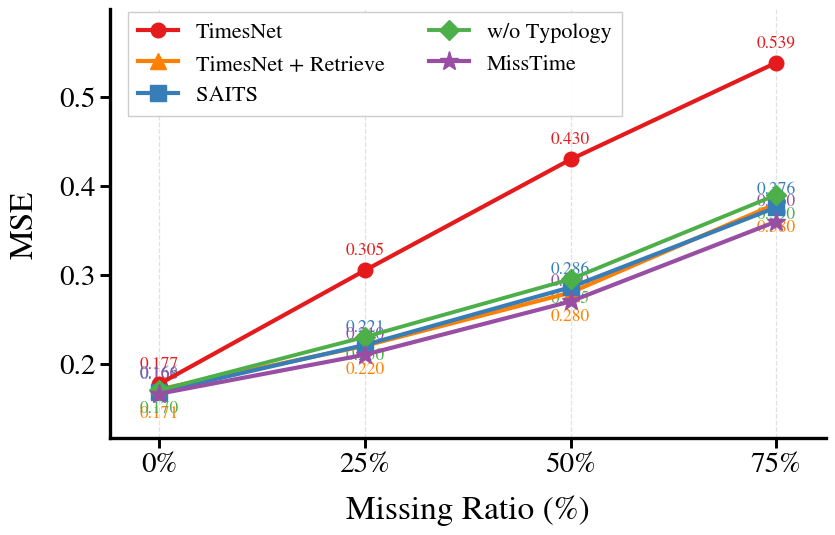

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data (5 methods x 4 ratios)
# =========================
missing_ratios = np.array([0, 25, 50, 75])

method_names = [
    "TimesNet",
    "TimesNet + Retrieve",
    "SAITS",
    "w/o Typology",
    "MissTime",
]

# 每一行对应一个方法；每一列对应 missing ratio = [0,25,50,75]
values = np.array([
    [0.177, 0.305, 0.430, 0.539],  # TimesNet
    [0.171, 0.220, 0.280, 0.380],  # TimesNet + Retrieve
    [0.168, 0.221, 0.286, 0.376],  # SAITS
    [0.170, 0.230, 0.295, 0.390],  # w/o Typology (示例，替换成你的真实值)
    [0.166, 0.210, 0.270, 0.360],  # MissTime (示例，替换成你的真实值)
], dtype=float)

assert values.shape == (5, 4), f"Expect (5,4), got {values.shape}"

# =========================
# Style
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 20,
    "axes.labelsize": 24,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 16,
    "axes.linewidth": 2.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(8.6, 5.6))

colors = ["#E41A1C", "#FF7F00", "#377EB8", "#4DAF4A", "#984EA3"]
markers = ["o", "^", "s", "D", "*"]
linew = [3.0, 3.0, 3.0, 2.8, 3.0]
msize = [10.5, 11.5, 11.0, 10.0, 14.0]

# 每条线的数值标注偏移（可按重叠情况微调）
label_dy = [0.013, -0.018, 0.011, -0.012, 0.014]

# =========================
# Plot all methods
# =========================
for i, name in enumerate(method_names):
    ys = values[i]
    ax.plot(
        missing_ratios, ys,
        marker=markers[i], markersize=msize[i], linewidth=linew[i],
        color=colors[i], markerfacecolor=colors[i], markeredgecolor=colors[i],
        label=name, zorder=4
    )

    for x, y in zip(missing_ratios, ys):
        dy = label_dy[i]
        ax.text(
            x, y + dy, f"{y:.3f}",
            ha="center",
            va="bottom" if dy >= 0 else "top",
            fontsize=12.5, color=colors[i]
        )

# =========================
# Axes
# =========================
ax.set_xlabel("Missing Ratio (%)", labelpad=12)
ax.set_ylabel("MSE", labelpad=14)

ax.set_xticks(missing_ratios)
ax.set_xticklabels([f"{v}%" for v in missing_ratios])

ymin = max(0.0, np.min(values) - 0.05)
ymax = np.max(values) + 0.06
ax.set_ylim(ymin, ymax)

ax.grid(axis="x", linestyle="--", linewidth=0.9, color="#D8D8D8", alpha=0.75, zorder=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2.4)
ax.spines["bottom"].set_linewidth(2.4)
ax.tick_params(axis="both", width=2.1, length=7, direction="out")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 1.02),
    ncol=2,
    frameon=True, fancybox=False, framealpha=0.98,
    edgecolor="#CCCCCC", facecolor="white",
    borderpad=0.45, handlelength=1.8
)

ax.margins(x=0.08)
plt.tight_layout(pad=0.8)

plt.savefig("retrieval_performance_line_5x4.pdf", dpi=600, bbox_inches="tight")
plt.savefig("retrieval_performance_line_5x4.png", dpi=400, bbox_inches="tight")
plt.show()


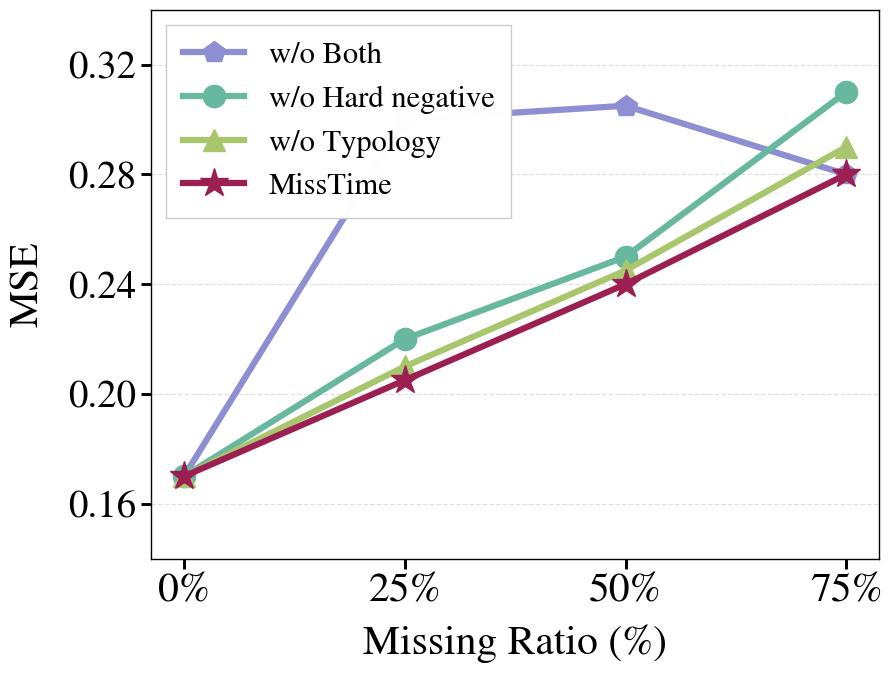

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

missing_ratios = np.array([0, 25, 50, 75])

series = {
    "w/o Both": np.array([0.170, 0.300, 0.305, 0.280]),
    "w/o Hard negative": np.array([0.170, 0.220, 0.250, 0.310]),
    "w/o Typology": np.array([0.170, 0.210, 0.245, 0.290]),
    "MissTime": np.array([0.170, 0.205, 0.240, 0.280]),
}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 21,
    "axes.labelsize": 25,
    "xtick.labelsize": 30,
    "ytick.labelsize": 28,
    "legend.fontsize": 22,
    "axes.linewidth": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "DejaVu Serif"],
#     "mathtext.fontset": "stix",
#     "font.size": 18,
#     "axes.labelsize": 19,
#     "xtick.labelsize": 16,
#     "ytick.labelsize": 17,
#     "legend.fontsize": 12.8,
#     "axes.linewidth": 1.0,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
# })


fig, ax = plt.subplots(figsize=(9.2, 7))

style = {
    "w/o Both": {"color": "#8D8FD2", "marker": "p"},
    "w/o Hard negative": {"color": "#67B89F", "marker": "o"},
    "w/o Typology": {"color": "#A8C66C", "marker": "^"},
    "MissTime": {"color": "#9C1F52", "marker": "*"},
}

for name, ys in series.items():
    ax.plot(
        missing_ratios, ys,
        marker=style[name]["marker"],
        markersize=16 if name != "MissTime" else 21,
        linewidth=4.5,
        color=style[name]["color"],
        markerfacecolor=style[name]["color"],
        markeredgecolor=style[name]["color"],
        label=name,
        zorder=4
    )

# ax.set_title("Electricity")
ax.set_xlabel("Missing Ratio (%)", labelpad=10, size=30)
ax.set_ylabel("MSE", labelpad=15, size=30)
ax.set_xticks(missing_ratios)
ax.set_xticklabels([f"{v}%" for v in missing_ratios])

ax.set_ylim(0.14, 0.34)
ax.set_yticks(np.arange(0.16, 0.35, 0.04))

ax.grid(axis="y", linestyle="--", linewidth=0.9, color="#D8D8D8", alpha=0.75, zorder=0)
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(1.0)
ax.tick_params(axis="both", width=2.1, length=7, direction="out")

ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.99,
    edgecolor="#CCCCCC",
    facecolor="white",
    borderpad=0.55,
    handlelength=2.0,
    ncol=1,
)

plt.tight_layout(pad=0.8)
plt.savefig("line_electricity.pdf", dpi=600, bbox_inches="tight")
plt.show()


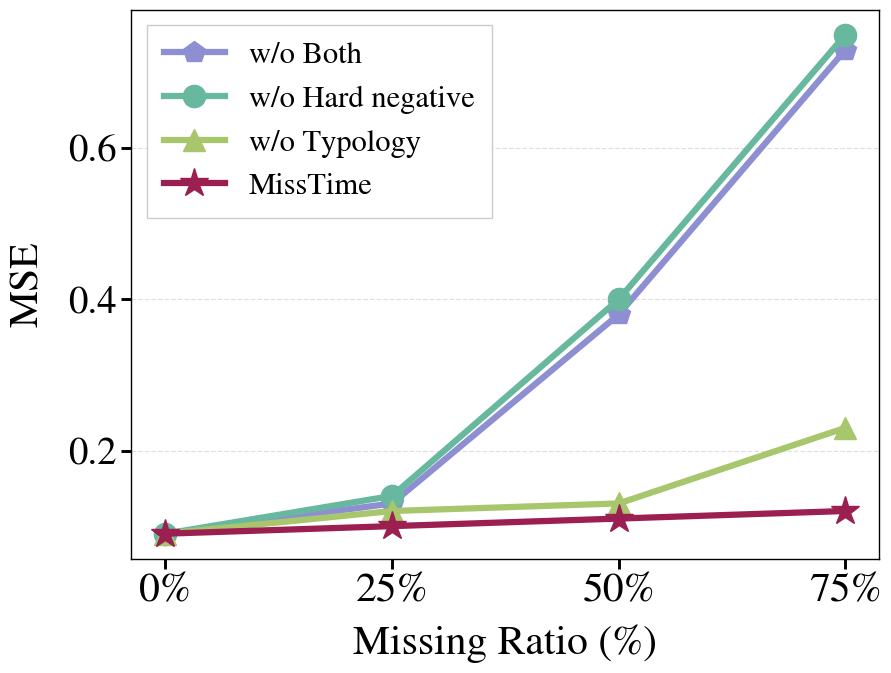

In [42]:
import numpy as np
import matplotlib.pyplot as plt

missing_ratios = [0, 25, 50, 75]

series = {
    "w/o Both": np.array([0.09, 0.13, 0.38, 0.73]),
    "w/o Hard negative": np.array([0.09, 0.14, 0.40, 0.75]),
    "w/o Typology": np.array([0.09, 0.12, 0.13, 0.23]),
    "MissTime": np.array([0.09, 0.10, 0.11, 0.12]),
}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 21,
    "axes.labelsize": 25,
    "xtick.labelsize": 30,
    "ytick.labelsize": 28,
    "legend.fontsize": 22,
    "axes.linewidth": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "DejaVu Serif"],
#     "mathtext.fontset": "stix",
#     "font.size": 18,
#     "axes.labelsize": 19,
#     "xtick.labelsize": 16,
#     "ytick.labelsize": 17,
#     "legend.fontsize": 12.8,
#     "axes.linewidth": 1.0,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
# })


fig, ax = plt.subplots(figsize=(9.2, 7))

style = {
    "w/o Both": {"color": "#8D8FD2", "marker": "p"},
    "w/o Hard negative": {"color": "#67B89F", "marker": "o"},
    "w/o Typology": {"color": "#A8C66C", "marker": "^"},
    "MissTime": {"color": "#9C1F52", "marker": "*"},
}

for name, ys in series.items():
    ax.plot(
        missing_ratios, ys,
        marker=style[name]["marker"],
        markersize=16 if name != "MissTime" else 21,
        linewidth=4.5,
        color=style[name]["color"],
        markerfacecolor=style[name]["color"],
        markeredgecolor=style[name]["color"],
        label=name,
        zorder=4
    )

# ax.set_title("Electricity")
ax.set_xlabel("Missing Ratio (%)", labelpad=10, size=30)
ax.set_ylabel("MSE", labelpad=15, size=30)
ax.set_xticks(missing_ratios)
ax.set_xticklabels([f"{v}%" for v in missing_ratios])

# ax.set_ylim(0.14, 0.34)
# ax.set_yticks(np.arange(0.16, 0.35, 0.04))

ax.grid(axis="y", linestyle="--", linewidth=0.9, color="#D8D8D8", alpha=0.75, zorder=0)
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(1.0)
ax.tick_params(axis="both", width=2.1, length=7, direction="out")

ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.99,
    edgecolor="#CCCCCC",
    facecolor="white",
    borderpad=0.55,
    handlelength=2.0,
    ncol=1,
)

plt.tight_layout(pad=0.8)
plt.savefig("line_pem.pdf", dpi=600, bbox_inches="tight")
plt.show()


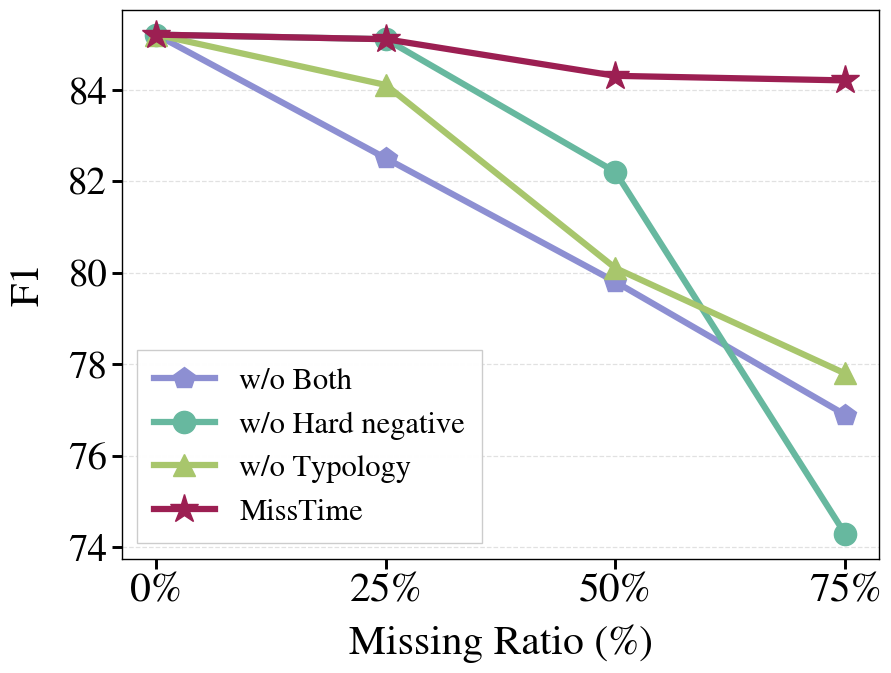

In [47]:
import numpy as np
import matplotlib.pyplot as plt

missing_ratios = [0, 25, 50, 75]

series = {
    "w/o Both": np.array([85.2, 82.5, 79.8, 76.9]),
    "w/o Hard negative": np.array([85.2, 85.1, 82.2, 74.3]),
    "w/o Typology": np.array([85.2, 84.1, 80.1, 77.8]),
    "MissTime": np.array([85.2, 85.1, 84.3, 84.2]),
}


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 21,
    "axes.labelsize": 25,
    "xtick.labelsize": 30,
    "ytick.labelsize": 28,
    "legend.fontsize": 22,
    "axes.linewidth": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "DejaVu Serif"],
#     "mathtext.fontset": "stix",
#     "font.size": 18,
#     "axes.labelsize": 19,
#     "xtick.labelsize": 16,
#     "ytick.labelsize": 17,
#     "legend.fontsize": 12.8,
#     "axes.linewidth": 1.0,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
# })


fig, ax = plt.subplots(figsize=(9.2, 7))

style = {
    "w/o Both": {"color": "#8D8FD2", "marker": "p"},
    "w/o Hard negative": {"color": "#67B89F", "marker": "o"},
    "w/o Typology": {"color": "#A8C66C", "marker": "^"},
    "MissTime": {"color": "#9C1F52", "marker": "*"},
}

for name, ys in series.items():
    ax.plot(
        missing_ratios, ys,
        marker=style[name]["marker"],
        markersize=16 if name != "MissTime" else 21,
        linewidth=4.5,
        color=style[name]["color"],
        markerfacecolor=style[name]["color"],
        markeredgecolor=style[name]["color"],
        label=name,
        zorder=4
    )

# ax.set_title("Electricity")
ax.set_xlabel("Missing Ratio (%)", labelpad=10, size=30)
ax.set_ylabel("F1", labelpad=15, size=30)
ax.set_xticks(missing_ratios)
ax.set_xticklabels([f"{v}%" for v in missing_ratios])

# ax.set_ylim(0.14, 0.34)
# ax.set_yticks(np.arange(0.16, 0.35, 0.04))

ax.grid(axis="y", linestyle="--", linewidth=0.9, color="#D8D8D8", alpha=0.75, zorder=0)
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(1.0)
ax.tick_params(axis="both", width=2.1, length=7, direction="out")

ax.legend(
    loc="lower left",
    frameon=True,
    fancybox=False,
    framealpha=0.99,
    edgecolor="#CCCCCC",
    facecolor="white",
    borderpad=0.55,
    handlelength=2.0,
    ncol=1,
)

plt.tight_layout(pad=0.8)
plt.savefig("line_smd.pdf", dpi=600, bbox_inches="tight")
plt.show()


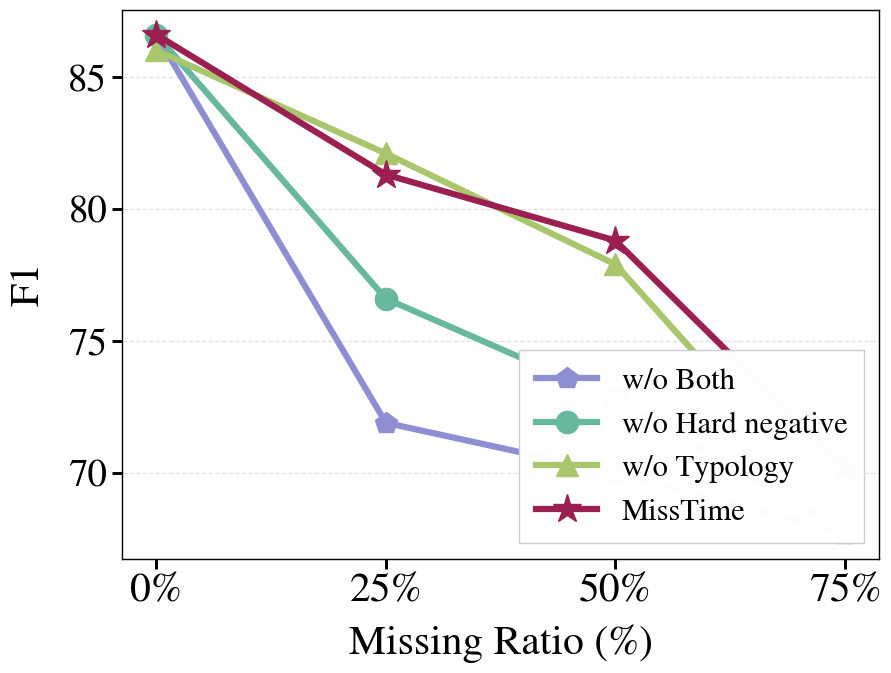

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

missing_ratios = [0, 25, 50, 75]

series = {
    # "TimesNet": np.array([86.6, 77.6, 57.6, 54.2]),
    "w/o Both": np.array([86.6, 71.9, 70.0, 67.7]),
    "w/o Hard negative": np.array([86.6, 76.6, 72.8, 67.8]),
    "w/o Typology": np.array([86.0, 82.1, 77.9, 68.2]),
    "MissTime": np.array([86.6, 81.3, 78.8, 70.2]),
}



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 21,
    "axes.labelsize": 25,
    "xtick.labelsize": 30,
    "ytick.labelsize": 28,
    "legend.fontsize": 22,
    "axes.linewidth": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral", "DejaVu Serif"],
#     "mathtext.fontset": "stix",
#     "font.size": 18,
#     "axes.labelsize": 19,
#     "xtick.labelsize": 16,
#     "ytick.labelsize": 17,
#     "legend.fontsize": 12.8,
#     "axes.linewidth": 1.0,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
# })


fig, ax = plt.subplots(figsize=(9.2, 7))

style = {
    "w/o Both": {"color": "#8D8FD2", "marker": "p"},
    "w/o Hard negative": {"color": "#67B89F", "marker": "o"},
    "w/o Typology": {"color": "#A8C66C", "marker": "^"},
    "MissTime": {"color": "#9C1F52", "marker": "*"},
}

for name, ys in series.items():
    ax.plot(
        missing_ratios, ys,
        marker=style[name]["marker"],
        markersize=16 if name != "MissTime" else 21,
        linewidth=4.5,
        color=style[name]["color"],
        markerfacecolor=style[name]["color"],
        markeredgecolor=style[name]["color"],
        label=name,
        zorder=4
    )

# ax.set_title("Electricity")
ax.set_xlabel("Missing Ratio (%)", labelpad=10, size=30)
ax.set_ylabel("F1", labelpad=15, size=30)
ax.set_xticks(missing_ratios)
ax.set_xticklabels([f"{v}%" for v in missing_ratios])

# ax.set_ylim(0.14, 0.34)
# ax.set_yticks(np.arange(0.16, 0.35, 0.04))

ax.grid(axis="y", linestyle="--", linewidth=0.9, color="#D8D8D8", alpha=0.75, zorder=0)
for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(1.0)
ax.tick_params(axis="both", width=2.1, length=7, direction="out")

ax.legend(
    loc="upper right",
    frameon=True,
    fancybox=False,
    framealpha=0.99,
    edgecolor="#CCCCCC",
    facecolor="white",
    borderpad=0.55,
    handlelength=2.0,
    ncol=1,
)

plt.tight_layout(pad=0.8)
plt.savefig("line_UGes.pdf", dpi=600, bbox_inches="tight")
plt.show()
